## Import Libraries for Heatmap generation

1) Plot without clustering
2) Split each feature into 3 different layers:
	1) Spatial, Texture, Intensity
	2) Cell Region
	3) SER-edge or STAR feature

#### z-scores: blue=low, white=mean, red=high.

In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [4]:
rng = np.random.default_rng(seed=42)

In [5]:
from sklearn.preprocessing import StandardScaler

# Initialise Data Path

In [6]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (20682, 1322)
counts (after):  (20682, 1322)


In [7]:
counts.head()

,Cell Type,Cellline ID,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,RM3.5,1964.49,473.458,2001,2964,747,1092250,24.1009,2558,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,RM3.5,2582.91,555.290,2683,3507,1303,883355,21.4986,3261,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,RM3.5,3105.96,806.695,2904,6924,1006,2963080,25.9725,4097,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,RM3.5,1677.06,552.588,1557,3253,779,753001,32.9498,2438,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,RM3.5,3321.61,796.328,3175,9111,1523,4354630,23.9741,4097,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702


### Calculate Aggregate level values

In [8]:
cell_line_agg_df = counts.groupby(['Cellline ID', 'Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df.shape)
print("cell_line_agg (after): ", cell_line_agg_df.shape)

cell_line_agg (before):  (13, 1320)
cell_line_agg (after):  (13, 1320)


#### Create additional labels for region, star types and feature types 

In [9]:
all_columns = cell_line_agg_df.columns
regions = []
feature_types = []
star_types = []
organelles = []

for col in all_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]
    region = f"{col_sections[2]} {col_sections[3]}"
    feature = col_sections[1]
    star_type = col_sections[4]
    regions.append(region)

    if star_type == 'Symmetry' or star_type == 'Threshold' or star_type == 'Axial' or star_type == 'Radial':
        star_types.append(star_type)
    else:
        star_types.append("None")
   
    feature_types.append(feature)
    organelles.append(organelle)


### Generate Heatmap without clustering

In [10]:
heatmap_data = cell_line_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: re.split(r'\W+', x)[0])
heatmap_data

,,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cellline ID,Cell Type,,,,,,,,,,,,,,,,,,,,,
01-060 C9,PRKN,2397.114860,1293.805829,2005.592018,9983.676275,926.840355,1.875812e+06,52.855346,3842.866962,0.232157,67.946315,...,0.065262,0.047551,0.053530,0.070469,0.743751,0.266924,0.642336,0.249505,0.000416,0.003145
09-090 C18,PRKN,1946.967211,2127.857417,1206.144343,18769.161198,506.857630,2.820884e+06,105.234601,3998.820154,-0.220533,130.065552,...,0.087697,0.052232,0.036871,0.097903,0.748054,0.361059,0.746866,0.322500,0.000715,0.005327
111450-107,Control,2515.278619,1090.267033,2192.716625,8956.351385,1179.583753,2.261869e+06,43.335420,3816.617128,0.163312,78.931746,...,0.066566,0.054189,0.048099,0.075258,0.733000,0.241992,0.452307,0.244027,0.000524,0.003997
11302-101,Control,2809.234488,958.642255,2568.322977,8513.619942,1404.583815,2.631833e+06,36.016652,3949.494942,0.219692,85.389591,...,0.068447,0.051690,0.045649,0.076666,0.723425,0.253551,0.452969,0.254463,0.000530,0.004026
11555-104,SNCA,2480.385462,1103.076554,2175.409756,9469.023415,1121.036098,2.414524e+06,43.835067,3753.430244,0.215947,86.073801,...,0.067242,0.054169,0.047672,0.075259,0.737148,0.268140,0.525461,0.255511,0.000503,0.003764
11556-110,SNCA,1640.041258,1645.694736,1094.231889,15174.415912,594.461190,2.056489e+06,91.588414,3051.448900,-0.131112,115.168152,...,0.070784,0.045249,0.029053,0.076389,0.732905,0.444822,0.825245,0.401549,0.000662,0.004694
11557-103,SNCA,2354.915873,1110.718500,2019.607656,9069.968421,936.360766,2.175820e+06,46.841877,3670.063158,0.250218,81.263283,...,0.063117,0.048410,0.048634,0.070107,0.755164,0.261815,0.557979,0.248481,0.000412,0.003101
11576-101,LRRK2,1470.152495,1268.766833,1056.077670,10608.302358,471.406380,1.837719e+06,69.614077,2754.846047,0.026012,98.174964,...,0.051716,0.033858,0.027448,0.055842,0.720464,0.206805,0.515336,0.349847,0.000440,0.003197
14555-107,LRRK2,2378.571557,1120.186412,2069.684814,9633.982808,986.262178,2.028495e+06,45.832643,3530.806590,0.298809,75.417705,...,0.065156,0.049727,0.049404,0.070891,0.738615,0.279009,0.558219,0.245275,0.000419,0.003110


In [11]:
heatmap_data = heatmap_data[sorted_columns]

In [12]:
heatmap_data

,,General Dimension - Nucleus region Area µm²,General Dimension - Nucleus region Roundness,General Dimension - Nucleus region Perimeter µm,General Dimension - Nucleus region Width µm,General Dimension - Nucleus region Length µm,General Dimension - Nucleus region Ratio Width to Length,General Dimension - Inner region Area µm²,General Dimension - Inner region Roundness,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Width µm,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cellline ID,Cell Type,,,,,,,,,,,,,,,,,,,,,
01-060 C9,PRKN,67.946315,0.914781,31.596994,7.122084,11.419451,0.639579,48.687567,0.333669,68.609308,3.152309,...,0.065262,0.047551,0.053530,0.070469,0.743751,0.266924,0.642336,0.249505,0.000416,0.003145
09-090 C18,PRKN,130.065552,0.838732,47.521225,8.713199,16.982723,0.542715,61.123065,0.270591,97.953138,2.898899,...,0.087697,0.052232,0.036871,0.097903,0.748054,0.361059,0.746866,0.322500,0.000715,0.005327
111450-107,Control,78.931746,0.920420,34.028156,7.744300,12.386339,0.641313,53.795965,0.331484,74.505125,3.121772,...,0.066566,0.054189,0.048099,0.075258,0.733000,0.241992,0.452307,0.244027,0.000524,0.003997
11302-101,Control,85.389591,0.924034,34.692041,7.999017,12.645884,0.647360,55.720516,0.319404,75.580352,2.990633,...,0.068447,0.051690,0.045649,0.076666,0.723425,0.253551,0.452969,0.254463,0.000530,0.004026
11555-104,SNCA,86.073801,0.915642,35.183439,7.951581,12.600431,0.654694,65.854881,0.336162,77.409949,3.368906,...,0.067242,0.054169,0.047672,0.075259,0.737148,0.268140,0.525461,0.255511,0.000503,0.003764
11556-110,SNCA,115.168152,0.833398,45.124623,8.345366,15.625873,0.563318,64.291799,0.288103,93.393290,3.053886,...,0.070784,0.045249,0.029053,0.076389,0.732905,0.444822,0.825245,0.401549,0.000662,0.004694
11557-103,SNCA,81.263283,0.915040,34.599771,7.748982,12.614239,0.629640,56.142437,0.330595,75.355107,3.289849,...,0.063117,0.048410,0.048634,0.070107,0.755164,0.261815,0.557979,0.248481,0.000412,0.003101
11576-101,LRRK2,98.174964,0.863077,38.954931,7.778117,13.942653,0.586682,71.723499,0.311442,83.246488,3.162907,...,0.051716,0.033858,0.027448,0.055842,0.720464,0.206805,0.515336,0.349847,0.000440,0.003197
14555-107,LRRK2,75.417705,0.918492,33.217232,7.545131,12.086598,0.638047,48.345514,0.322944,71.660942,3.041711,...,0.065156,0.049727,0.049404,0.070891,0.738615,0.279009,0.558219,0.245275,0.000419,0.003110


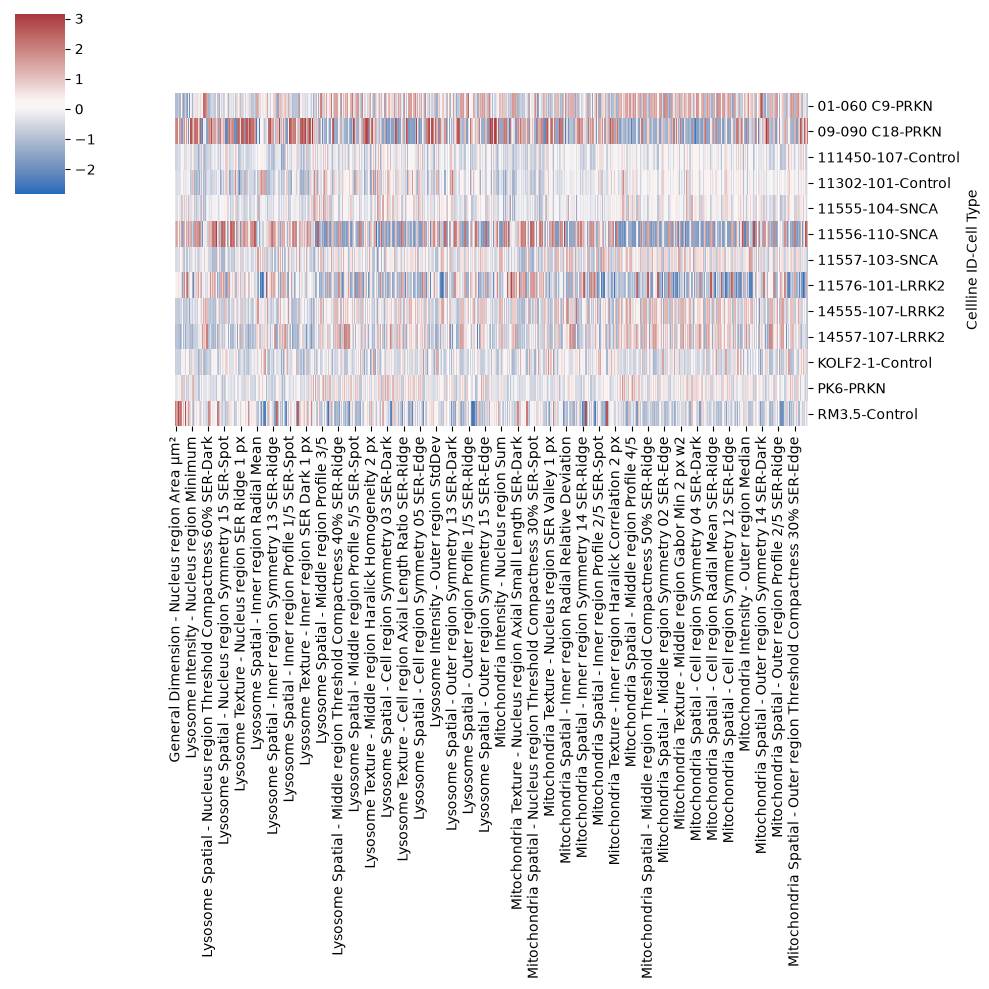

In [13]:
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
)

## Begin adding additional labels

In [14]:
set(organelles)

{'General', 'Lysosome', 'Mitochondria'}

In [15]:
set(regions)

{'Cell region',
 'Inner region',
 'Middle region',
 'Nucleus region',
 'Outer region'}

In [16]:
set(star_types)

{'Axial', 'None', 'Radial', 'Symmetry', 'Threshold'}

In [17]:
set(feature_types)

{'Dimension', 'Intensity', 'Spatial', 'Texture'}

/tmp/ipykernel_293569/2532374668.py:121: UserWarning: Mismatched number of handles and labels: len(handles) = 17 len(labels) = 4
  plt.legend(handles + handles_2 + handles_3 + handles_4, lut_feature, title='Feature',


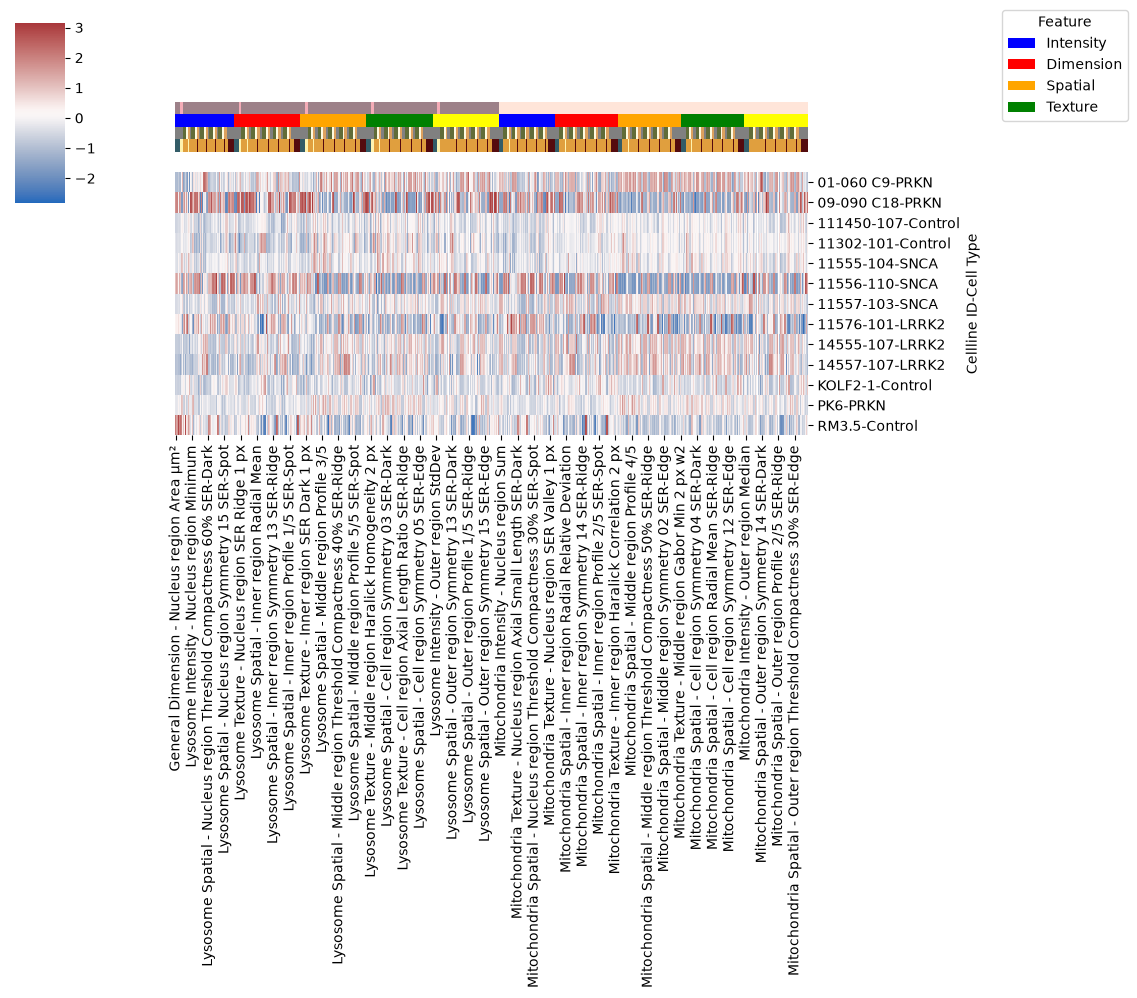

In [18]:
# Initialise an organelles array
organelle_colors = [

]

lut_organelle = {

}

for organelle in organelles:
    color = 'Grey'
    if organelle == 'General':
        color = '#f4acb7'
    elif organelle == 'Mitochondria':
        color = '#ffe5d9'
    else:
        color = '#9d8189'

    lut_organelle[organelle] = color
    organelle_colors.append(color)

# Initialise a colours array
region_colors = [

]

lut = {

}


# Initialise a colours array for STAR
star_colors = [

]

lut_star = {

}
for star in star_types:
    if star == 'None':
        star_color = 'Grey'
    elif star == 'Symmetry':
        star_color = '#606c38'
    elif star == 'Threshold':
        star_color = '#fefae0'
    elif star == 'Axial':
        star_color = '#dda15e'
    else:
        star_color = '#dda15e'

    lut_star[star] = star_color
    star_colors.append(star_color)
    


# Go over each region
for region in regions:
    if region == 'Nucleus region':
        region_color = 'Blue'
        lut['Nucleus region'] = 'Blue'
    elif region == 'Inner region':
        region_color = 'Red'
        lut['Inner region'] = 'Red'
    elif region == 'Middle region':
        region_color = 'Orange'
        lut['Middle region'] = 'Orange'
    elif region == 'Outer region':
        region_color = 'Yellow'
        lut['Outer region'] = 'Yellow'
    elif region == 'Cell region':
        region_color = 'Green'
        lut['Cell region'] = 'Green'

    lut[region] = region_color
    region_colors.append(region_color)

# Feature colours
feature_colours = []
lut_feature = {

}
for feature in feature_types:
    if feature == 'Intensity':
        feature_color = '#335c67'
    elif feature == 'Dimension':
        feature_color = '#fff3b0'
    elif feature == 'Spatial':
        feature_color = '#e09f3e'
    else:
        feature_color = '#540b0e'

    lut_feature[feature] = feature_color

    feature_colours.append(feature_color)


# Figure this legend part out later
handles = [Patch(facecolor=lut[name]) for name in lut]
handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]

g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

plt.legend(handles + handles_2 + handles_3 + handles_4, lut_feature, title='Feature',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')

# plt.legend(handles_2, lut_star, title='STAR',
#            bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='lower right')


# plt.legend(handles, lut, title='Region',
#            bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')


# plt.legend(handles_4, lut_organelle, title='Organelle',
#            bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')

